# Titanic Dataset - Mini Exploratory Data Analysis (EDA)

## Internship Task 3

### Objective
Perform Exploratory Data Analysis (EDA) on the Titanic dataset to discover survival patterns and visualize important insights.

### Tools Used
- Python
- Pandas
- Matplotlib
- Seaborn
- Google Colab

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load Dataset

Load the Titanic dataset into a Pandas DataFrame.

In [4]:
df = pd.read_csv("train.csv")

# Preview Dataset

Display first 5 rows of the dataset.

In [5]:
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


# Dataset Information

Check:
- Rows and columns
- Data types
- Missing values

In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


# Check Missing Values

Identify columns containing null values.

In [7]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


# Data Cleaning

Perform:
- Fill missing Age values using mean
- Fill missing Embarked values using mode
- Drop Cabin column

In [8]:
df["Age"] = df["Age"].fillna(df["Age"].mean())

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

df.drop(columns=["Cabin"], inplace=True)


# Verify Cleaned Dataset

Recheck missing values after cleaning.

In [9]:
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


# Create Age Groups

Passengers are categorized into:
- Child
- Teen
- Young Adult
- Adult
- Senior

In [10]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 12, 18, 30, 50, 80],
    labels=["Child", "Teen", "Young Adult", "Adult", "Senior"]
)

# Survival Rate by Age Group

Analyze survival chances across different age groups.

In [11]:
age_survival = df.groupby("AgeGroup")["Survived"].mean()

print(age_survival)

AgeGroup
Child          0.579710
Teen           0.428571
Young Adult    0.331096
Adult          0.423237
Senior         0.343750
Name: Survived, dtype: float64


/tmp/ipykernel_1763/1538592258.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_survival = df.groupby("AgeGroup")["Survived"].mean()


# Visualization: Survival Rate by Age Group

This bar plot shows survival rates for each age category.

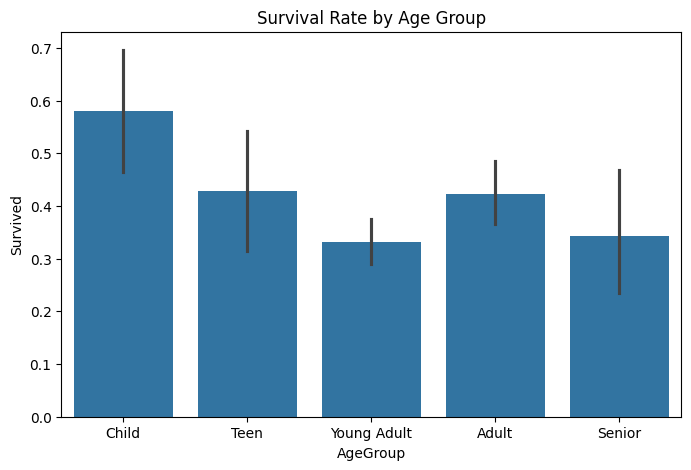

In [12]:
plt.figure(figsize=(8,5))

sns.barplot(x="AgeGroup", y="Survived", data=df)

plt.title("Survival Rate by Age Group")

plt.show()

# Survival Rate by Embarkation Port

Analyze survival rates based on passenger embarkation ports.

In [13]:
embark_survival = df.groupby("Embarked")["Survived"].mean()

print(embark_survival)

Embarked
C    0.553571
Q    0.389610
S    0.339009
Name: Survived, dtype: float64


# Visualization: Survival by Embarkation Port

This chart compares survival rates across embarkation ports.

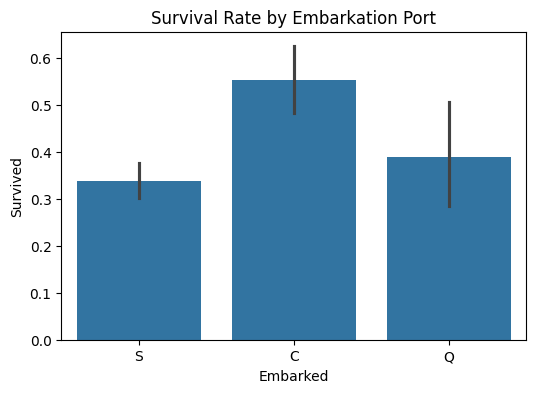

In [14]:
plt.figure(figsize=(6,4))

sns.barplot(x="Embarked", y="Survived", data=df)

plt.title("Survival Rate by Embarkation Port")

plt.show()

# Create Family Size Feature

Family size is calculated using:
- SibSp (siblings/spouses)
- Parch (parents/children)

In [15]:
df["FamilySize"] = df["SibSp"] + df["Parch"]

# Survival Rate by Family Size

Analyze how family size affected passenger survival.

In [16]:
family_survival = df.groupby("FamilySize")["Survived"].mean()

print(family_survival)

FamilySize
0     0.303538
1     0.552795
2     0.578431
3     0.724138
4     0.200000
5     0.136364
6     0.333333
7     0.000000
10    0.000000
Name: Survived, dtype: float64


# Visualization: Survival by Family Size

This bar plot shows survival rates for different family sizes.

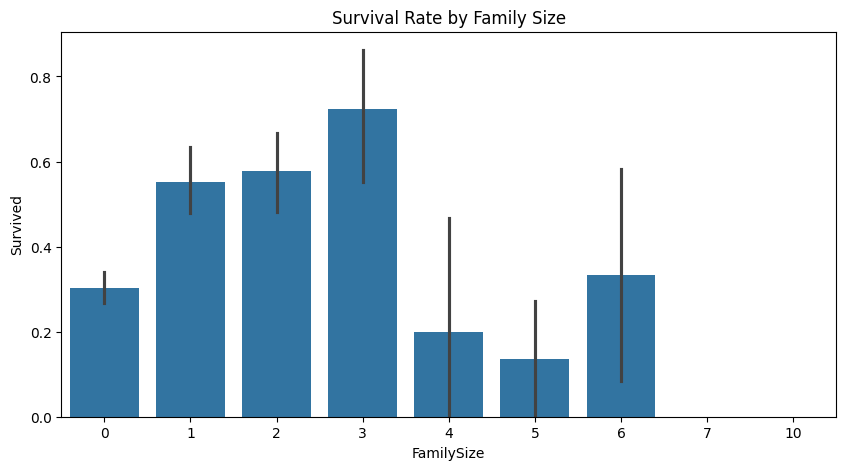

In [17]:
plt.figure(figsize=(10,5))

sns.barplot(x="FamilySize", y="Survived", data=df)

plt.title("Survival Rate by Family Size")

plt.show()

# Age Distribution Histogram

Visualize the distribution of passenger ages.

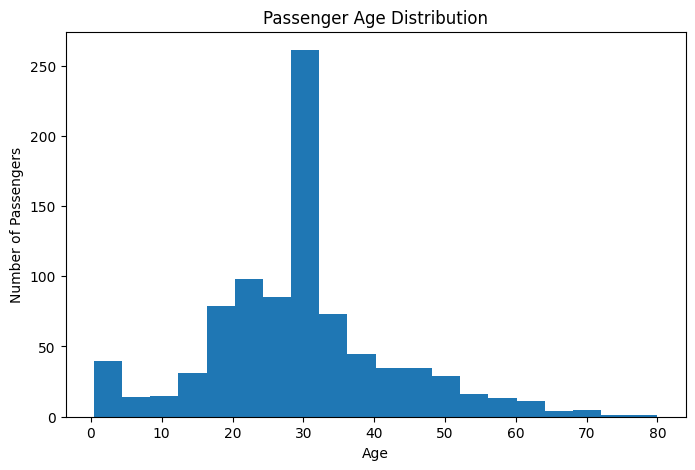

In [18]:
plt.figure(figsize=(8,5))

plt.hist(df["Age"], bins=20)

plt.title("Passenger Age Distribution")

plt.xlabel("Age")

plt.ylabel("Number of Passengers")

plt.show()

# Correlation Heatmap

Analyze relationships between numerical features.

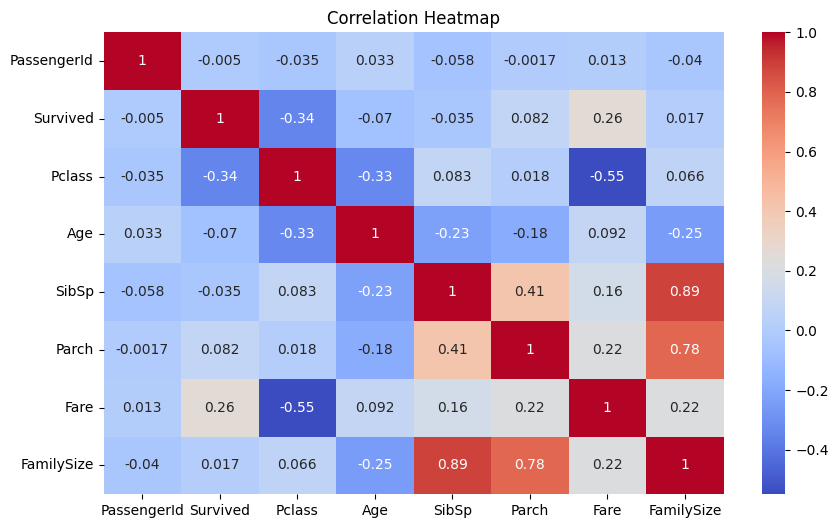

In [20]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

# Final Conclusion

## Key Insights
1. Adults and young adults had better survival rates.
2. Embarkation port influenced survival chances.
3. Moderate family sizes had better survival rates.
4. Heatmaps helped identify correlations between numerical features.
5. EDA improved understanding of passenger survival patterns.

